In [52]:
using DrWatson
@quickactivate "TwoPhotonLocking"

using Plots
using TwoPhotonLocking: number_op, wigner, g2
using TwoPhotonLocking: Gₑ, Δₑ, gf, cf
using OhMyThreads

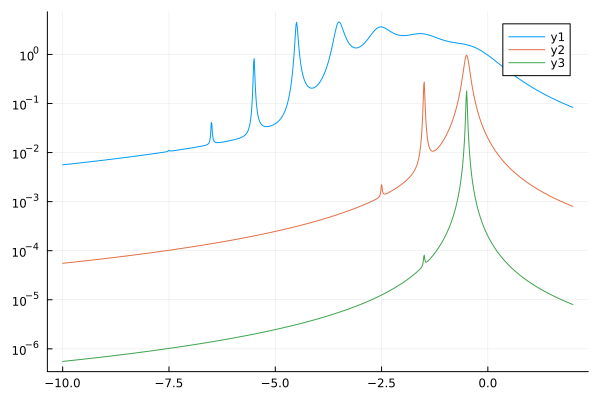

In [37]:
plot(Δ -> number_op(Δ, 1, -1, 0.03), range(-10,2, 1000), yscale=:log10)
plot!(Δ -> number_op(Δ, 0.1, -1, 0.03), range(-10,2, 1000))
plot!(Δ -> number_op(Δ, 0.01, -1, 0.03), range(-10,2, 1000))

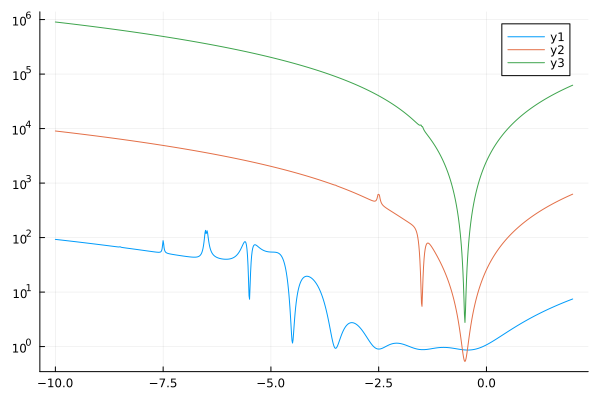

In [38]:
plot(Δ -> g2(Δ, 1, -1, 0.03), range(-10,2, 1000), yscale=:log10)
plot!(Δ -> g2(Δ, 0.1, -1, 0.03), range(-10,2, 1000))
plot!(Δ -> g2(Δ, 0.01, -1, 0.03), range(-10,2, 1000))

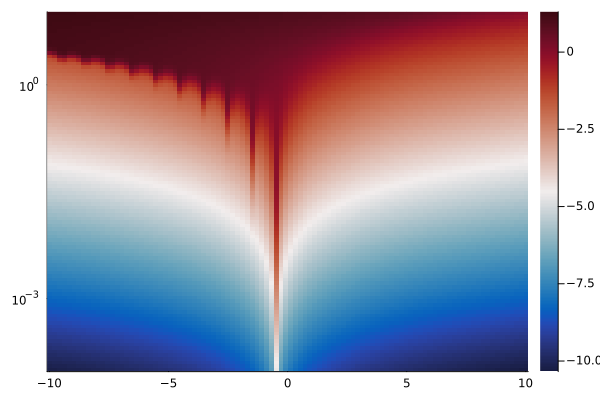

In [39]:
Δrange = range(-10, 10, 100)
Grange = 10 .^ range(-4, 1, 100)
range2d = Iterators.product(Δrange, Grange)
mpr = map(range2d) do (Δ, G)
    number_op(Δ, G, -1.0, 0.03)
end
heatmap(Δrange, Grange, log10.(mpr)', c=:balance, yscale=:log10, cscale=:log10)

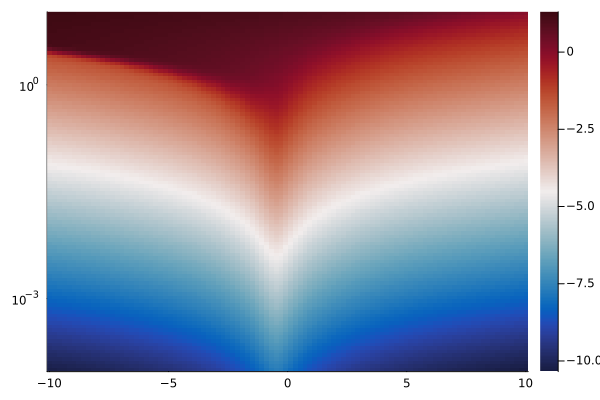

In [40]:
Δrange = range(-10, 10, 100)
Grange = 10 .^ range(-4, 1, 100)
range2d = Iterators.product(Δrange, Grange)
mpr = map(range2d) do (Δ, G)
    number_op(Δ, G, -1.0, 1.0)
end
heatmap(Δrange, Grange, log10.(mpr)', c=:balance, yscale=:log10, cscale=:log10)

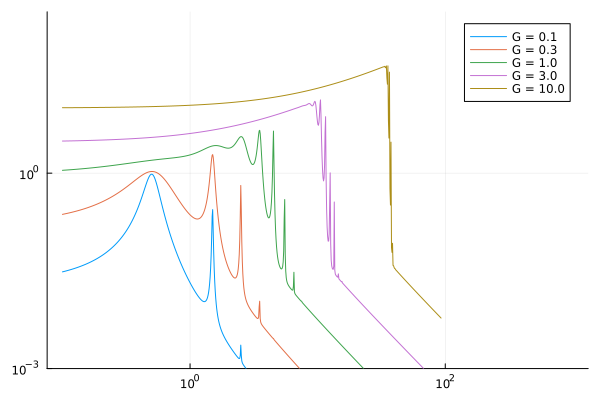

┌ Warning: Invalid negative or zero value 0.0 found at series index 749 for log10 based yscale
└ @ Plots ~/.julia/packages/Plots/Ec1L1/src/utils.jl:106
┌ Warning: Invalid negative or zero value 0.0 found at series index 749 for log10 based yscale
└ @ Plots ~/.julia/packages/Plots/Ec1L1/src/utils.jl:106
┌ Warning: Invalid negative or zero value 0.0 found at series index 749 for log10 based yscale
└ @ Plots ~/.julia/packages/Plots/Ec1L1/src/utils.jl:106


In [16]:
p = plot(Δ -> number_op(Δ, 0.1, 1, 0.03), 10 .^ range(-1,3, 1000), yscale=:log10, xscale=:log10, label="G = 0.1")
for G in [0.3, 1, 3,10]
    plot!(Δ -> number_op(Δ, G, 1, 0.03), 10 .^ range(-1,3, 1000), ylims=(1e-3, 300), label="G = $G")
end
p 

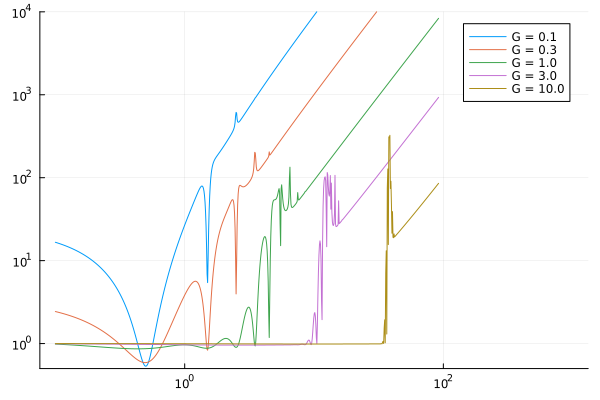

In [17]:
p = plot(Δ -> g2(Δ, 0.1, 1, 0.03), 10 .^ range(-1,3, 1000), yscale=:log10, xscale=:log10, label="G = 0.1")
for G in [0.3, 1, 3,10]
    plot!(Δ -> g2(Δ, G, 1, 0.03), 10 .^ range(-1,3, 1000), ylims=(0.5, 10000), label="G = $G")
end
p 

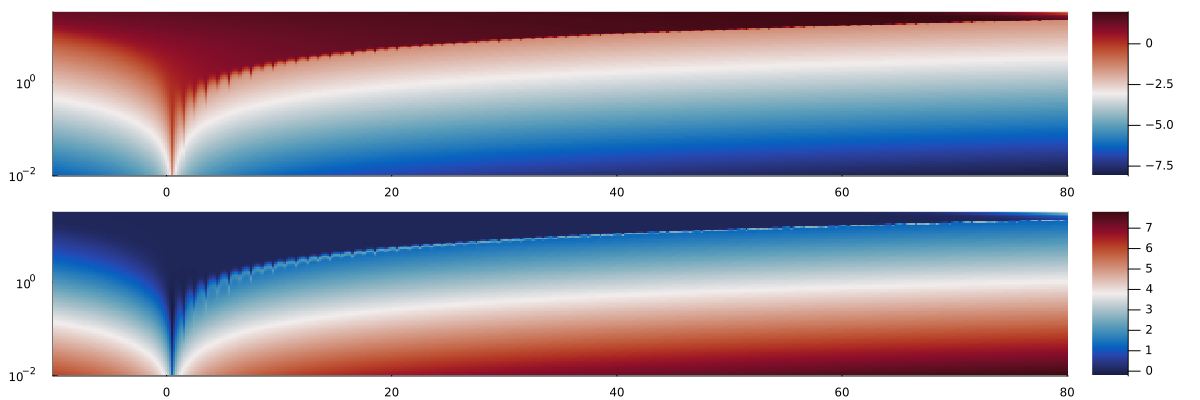

In [79]:
Δrange = range(-10, 80, 500)
Grange = 10 .^ range(-2, 1.5, 100)
range2d = Iterators.product(Δrange, Grange) |> collect
mpr = tmap(tt-> number_op(tt[1], tt[2], 1.0, 0.03), range2d) 
g2m = tmap(tt-> g2(tt[1], tt[2], 1.0, 0.03), range2d) 
plot(
heatmap(Δrange, Grange, log10.(mpr)', c=:balance, yscale=:log10, cscale=:log10),
heatmap(Δrange, Grange, log10.(g2m)', c=:balance, yscale=:log10, cscale=:log10),
size = (1200, 400), layout = (2,1)
)

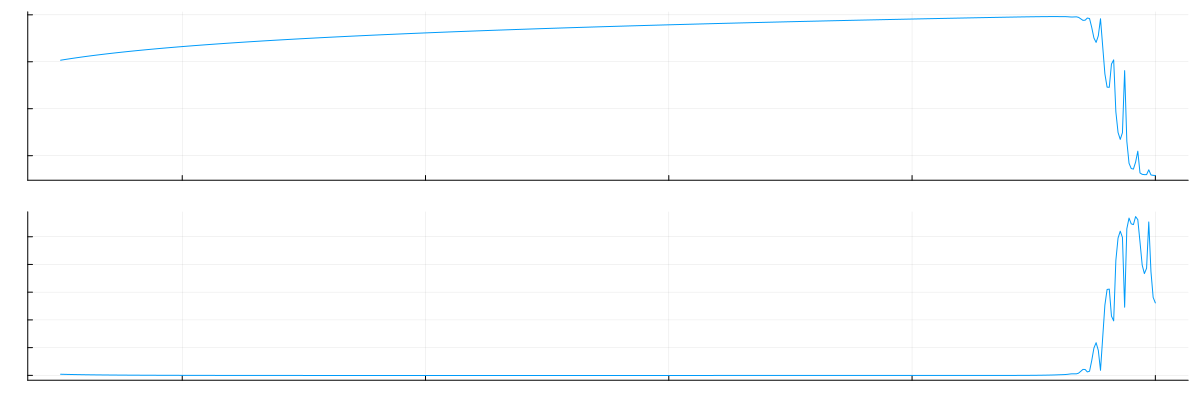

In [86]:
plot(
    plot(Δrange, log10.(mpr')[95,:]),
    plot(Δrange, log10.(g2m')[95,:]),
    size = (1200, 400), layout = (2,1)
)

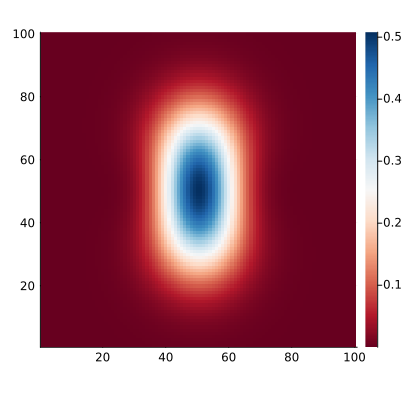

In [19]:
range2d = Iterators.product(range(-2.2, 2.2, length = 100), range(-2.2, 2.2, length = 100))
𝔚 = map(range2d) do (x,y)
    z = x + im*y
    w = wigner(z, 1, 1, -1, 0.03; max_m = 100)
end
heatmap(𝔚, c=:RdBu, aspect_ratio=1, size=(410,400))
